# Day 15 — Portfolio Risk Attribution

## Objective
Measure each stock's contribution to portfolio risk
and identify potential concentration risk.

## Methodology
Use historical returns, portfolio weights and the
covariance matrix to calculate marginal and percentage
contributions to portfolio volatility.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the existing five-stock dataset
prices = pd.read_csv(
    "five_stock_prices.csv",
    index_col=0,
    parse_dates=True
)

returns = prices.pct_change().dropna()

print("Stocks:", list(returns.columns))
print("Observations:", len(returns))
display(returns.head())

Stocks: ['AAPL', 'BLK', 'GS', 'JPM', 'MSFT']
Observations: 249


,AAPL,BLK,GS,JPM,MSFT
Date,,,,,
2025-09-24,-0.008332,-0.003331,-0.017226,0.002174,0.001807
2025-09-25,0.018073,0.017119,0.002940,0.000096,-0.006116
2025-09-26,-0.005489,0.007984,0.009751,0.008327,0.008737
2025-09-29,-0.004032,0.016525,0.002006,-0.001171,0.006139
2025-09-30,0.000786,-0.008243,-0.009663,-0.000824,0.006510


In [2]:

# Day 15 — Step 2: Portfolio risk attribution

stocks = list(returns.columns)
n = len(stocks)

# Start with equal weights
weights = np.ones(n) / n

# Annualized covariance matrix
cov_matrix = returns.cov() * 252

# Annualized portfolio volatility
portfolio_vol = np.sqrt(
    weights @ cov_matrix.values @ weights
)

# Marginal contribution to volatility
marginal_risk = (
    cov_matrix.values @ weights
) / portfolio_vol

# Component contribution to volatility
component_risk = weights * marginal_risk

# Percentage contribution to total risk
risk_contribution_pct = (
    component_risk / portfolio_vol
) * 100

risk_attribution = pd.DataFrame({
    "Portfolio Weight (%)": weights * 100,
    "Risk Contribution (%)": risk_contribution_pct,
    "Volatility Contribution (pp)": component_risk * 100
}, index=stocks)

display(risk_attribution.round(2))

print(f"Portfolio volatility: {portfolio_vol:.2%}")
print(
    "Total risk contribution:",
    f"{risk_contribution_pct.sum():.2f}%"
)

assert np.isclose(risk_contribution_pct.sum(), 100)

,Portfolio Weight (%),Risk Contribution (%),Volatility Contribution (pp)
AAPL,20.0,14.12,2.57
BLK,20.0,22.78,4.15
GS,20.0,27.69,5.05
JPM,20.0,16.62,3.03
MSFT,20.0,18.79,3.43


Portfolio volatility: 18.23%
Total risk contribution: 100.00%


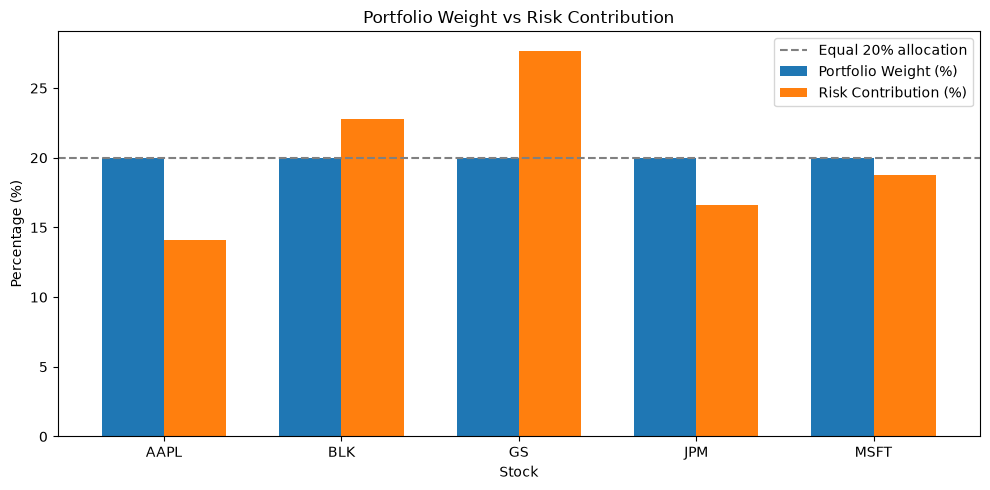

In [3]:

# Compare capital allocation with risk contribution

comparison = risk_attribution[
    ["Portfolio Weight (%)", "Risk Contribution (%)"]
]

ax = comparison.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.7
)

ax.set_title("Portfolio Weight vs Risk Contribution")
ax.set_xlabel("Stock")
ax.set_ylabel("Percentage (%)")
ax.axhline(20, linestyle="--", color="gray",
           label="Equal 20% allocation")
ax.legend()

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [4]:

from scipy.optimize import minimize

cov = cov_matrix.values

def risk_contributions(w, cov):
    volatility = np.sqrt(w @ cov @ w)
    marginal = (cov @ w) / volatility
    components = w * marginal
    return components / volatility

def risk_parity_objective(w):
    contributions = risk_contributions(w, cov)
    target = np.ones(len(w)) / len(w)
    return np.sum((contributions - target) ** 2)

result = minimize(
    risk_parity_objective,
    x0=np.ones(n) / n,
    method="SLSQP",
    bounds=[(0, 1)] * n,
    constraints=[
        {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    ],
    options={"ftol": 1e-12, "maxiter": 1000}
)

if not result.success:
    raise RuntimeError(result.message)

rp_weights = result.x
rp_risk = risk_contributions(rp_weights, cov) * 100

comparison = pd.DataFrame({
    "Equal Weight Allocation (%)": weights * 100,
    "Equal Weight Risk (%)": risk_contribution_pct,
    "Risk Parity Allocation (%)": rp_weights * 100,
    "Risk Parity Risk (%)": rp_risk
}, index=stocks)

display(comparison.round(2))

print("Risk parity allocation total:",
      round(rp_weights.sum() * 100, 2), "%")

print("Risk contribution total:",
      round(rp_risk.sum(), 2), "%")

,Equal Weight Allocation (%),Equal Weight Risk (%),Risk Parity Allocation (%),Risk Parity Risk (%)
AAPL,20.0,14.12,24.51,20.0
BLK,20.0,22.78,17.46,20.0
GS,20.0,27.69,14.78,20.0
JPM,20.0,16.62,23.17,20.0
MSFT,20.0,18.79,20.08,20.0


Risk parity allocation total: 100.0 %
Risk contribution total: 100.0 %


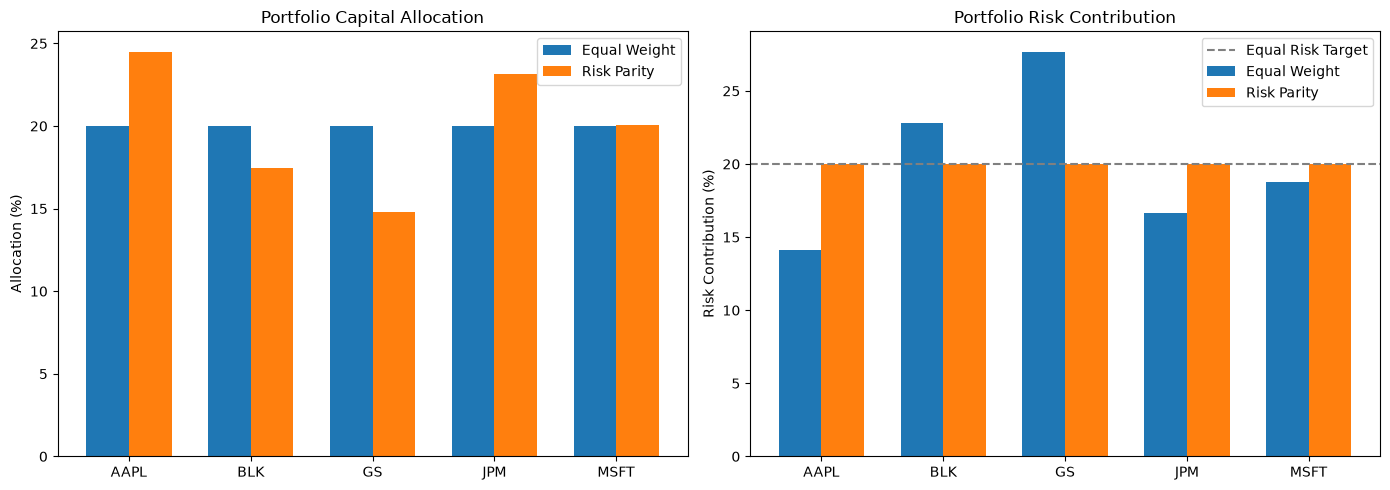

In [5]:

# Step 5: Compare equal-weight and risk-parity portfolios

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(stocks))
width = 0.35

# Chart 1: Capital allocation
axes[0].bar(
    x - width / 2,
    comparison["Equal Weight Allocation (%)"],
    width,
    label="Equal Weight"
)

axes[0].bar(
    x + width / 2,
    comparison["Risk Parity Allocation (%)"],
    width,
    label="Risk Parity"
)

axes[0].set_title("Portfolio Capital Allocation")
axes[0].set_ylabel("Allocation (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(stocks)
axes[0].legend()

# Chart 2: Risk contribution
axes[1].bar(
    x - width / 2,
    comparison["Equal Weight Risk (%)"],
    width,
    label="Equal Weight"
)

axes[1].bar(
    x + width / 2,
    comparison["Risk Parity Risk (%)"],
    width,
    label="Risk Parity"
)

axes[1].axhline(
    20,
    linestyle="--",
    color="gray",
    label="Equal Risk Target"
)

axes[1].set_title("Portfolio Risk Contribution")
axes[1].set_ylabel("Risk Contribution (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(stocks)
axes[1].legend()

plt.tight_layout()
plt.show()

### Day 15 — Research Conclusion

An equal-weight portfolio allocates capital equally but does not distribute portfolio risk equally. In this five-stock sample, Goldman Sachs contributed 27.69% of total portfolio volatility despite receiving only a 20% capital allocation.

Risk-parity optimization adjusted capital allocations to target a 20% risk contribution from each stock. Goldman Sachs' allocation decreased to 14.78%, while Apple's increased to 24.51%.

These findings demonstrate the importance of covariance-based risk attribution in portfolio construction. Risk parity balances estimated volatility contributions; it does not guarantee lower losses, higher returns or equal risk during future market shocks.

**Limitations:** Results depend on historical covariance estimates, the selected securities and the estimation period. The optimization also excludes transaction costs and constraints on future portfolio turnover.
